<a href="https://colab.research.google.com/github/emortalizer/Colab-Assignment-12-BMW/blob/main/Assignment_twelve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ====================== library Imports ======================
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


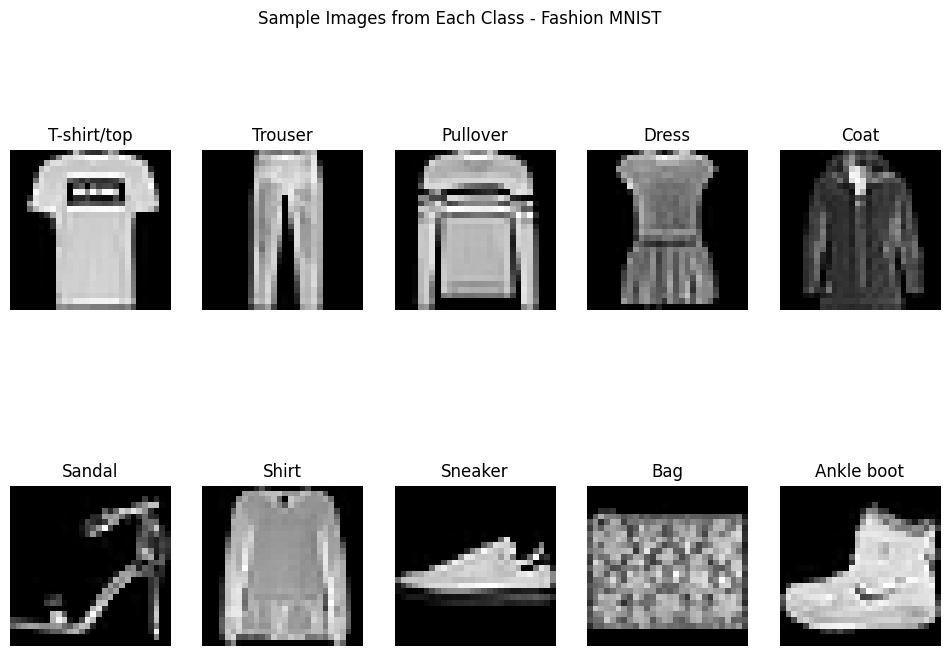

Training samples: 60000 | Test samples: 10000
Image shape: (28, 28) (28x28 grayscale)


In [2]:
# ====================== Load & Visualize Dataset ======================
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize one sample from each class
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    idx = np.where(y_train == i)[0][0]
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Sample Images from Each Class - Fashion MNIST')
plt.show()

print(f"Training samples: {x_train.shape[0]} | Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]} (28x28 grayscale)")

In [3]:
# ====================== Preprocessing ======================
# Normalization (scale to 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels for categorical crossentropy
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Data normalized and labels one-hot encoded.")

Data normalized and labels one-hot encoded.


In [4]:
# ====================== Build Simple Feedforward NN ======================
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.summary()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ====================== Training ======================
history = model.fit(x_train, y_train_cat,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7838 - loss: 0.6024 - val_accuracy: 0.8460 - val_loss: 0.4213
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8431 - loss: 0.4345 - val_accuracy: 0.8638 - val_loss: 0.3761
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8544 - loss: 0.3966 - val_accuracy: 0.8647 - val_loss: 0.3598
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8645 - loss: 0.3731 - val_accuracy: 0.8730 - val_loss: 0.3558
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8684 - loss: 0.3608 - val_accuracy: 0.8730 - val_loss: 0.3434
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8732 - loss: 0.3456 - val_accuracy: 0.8745 - val_loss: 0.3349
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8767 - loss: 0.3338 - val_accuracy: 0.8752 - val_loss: 0.3359
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8805 - loss: 0.3283 - val_accuracy: 0

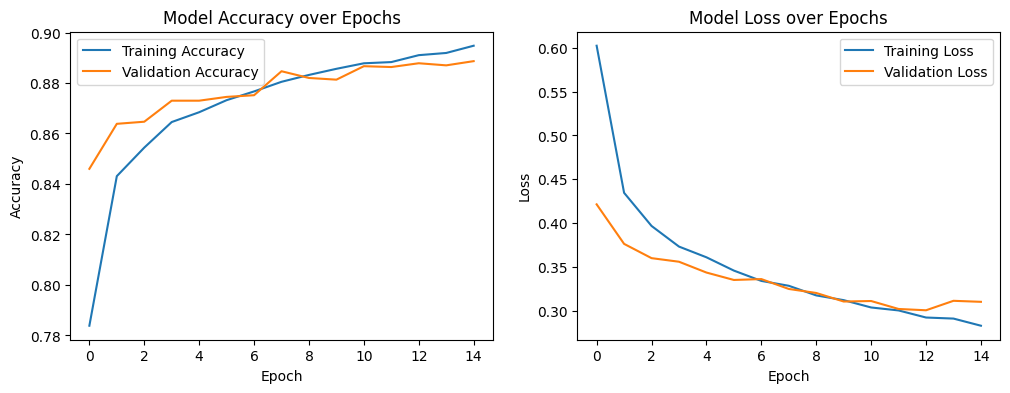

In [6]:
# ====================== Training Curves ======================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


Test Accuracy: 0.8839 (88.39%)

=== Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top     0.8353    0.8370    0.8362      1000
     Trouser     0.9868    0.9720    0.9793      1000
    Pullover     0.7771    0.8020    0.7894      1000
       Dress     0.8967    0.8770    0.8868      1000
        Coat     0.7504    0.8630    0.8028      1000
      Sandal     0.9836    0.9600    0.9717      1000
       Shirt     0.7482    0.6330    0.6858      1000
     Sneaker     0.9192    0.9790    0.9482      1000
         Bag     0.9731    0.9760    0.9745      1000
  Ankle boot     0.9761    0.9400    0.9577      1000

    accuracy                         0.8839     10000
   macro avg     0.8847    0.8839    0.8832     10000
weighted avg     0.8847    0.8839    0.8832     10000



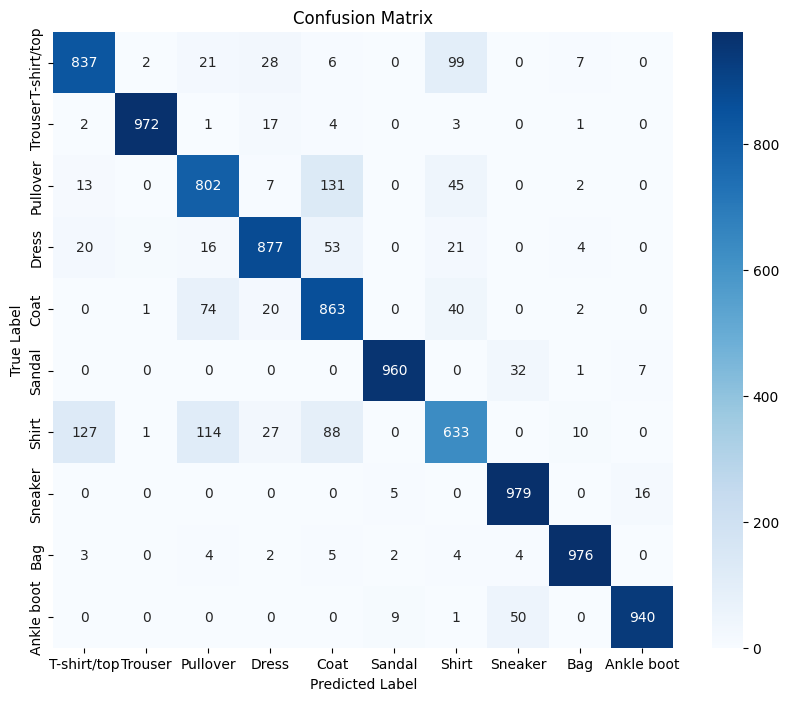

In [7]:
# ====================== Evaluation & Metrics ======================
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Predictions
y_pred_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

1. Test accuracy: ~88–90%
2. Strong performance on trousers, bags, ankle boots; some confusion between visually similar items (shirt ↔ t-shirt/top ↔ pullover).
3. Training curves will show steady improvement with minimal overfitting thanks to Dropout.